In [73]:
# Bibliotecas padrão do Python
import io
import pickle
import re
from contextlib import redirect_stdout

# Bibliotecas de terceiros
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from scipy.stats import boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from unidecode import unidecode

### ETL

#### Extracao

In [2]:
# Leitura arquivo csv
df_mp_original = pd.read_csv("../data/biodiesel-materia-prima.csv")

In [3]:
# Verificando as primeiras 5 linhas do dataframe
df_mp_original.head()


,Mês/Ano,Região,Estado,Produto,Quantidade (m³)
0,08/2023,CENTRO OESTE,Goiás,ÁCIDO GRAXO DE ÓLEO DE SOJA,652
1,08/2023,CENTRO OESTE,Mato Grosso,ÁCIDO GRAXO DE ÓLEO DE SOJA,956
2,08/2023,SUDESTE,São Paulo,ÁCIDO GRAXO DE ÓLEO DE SOJA,511
3,08/2023,CENTRO OESTE,Goiás,GORDURA BOVINA,6595
4,08/2023,CENTRO OESTE,Mato Grosso,GORDURA BOVINA,447


In [4]:
# Verificando as info do dataframe
df_mp_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Mês/Ano          4745 non-null   str  
 1   Região           4745 non-null   str  
 2   Estado           4745 non-null   str  
 3   Produto          4745 non-null   str  
 4   Quantidade (m³)  4745 non-null   int64
dtypes: int64(1), str(4)
memory usage: 185.5 KB


In [5]:

#Verificando se as variaveis estao na mesma escala 
df_mp_original.describe()

,Quantidade (m³)
count,4745.000000
mean,8411.538462
std,19047.244330
min,0.000000
25%,322.000000
50%,1849.000000
75%,6518.000000
max,150567.000000


In [6]:
# Verificando quais as colunas do dataframe
df_mp_original.columns

Index(['Mês/Ano', 'Região', 'Estado', 'Produto', 'Quantidade (m³)'], dtype='str')

In [7]:
# Verificando quant. de linhas e colunas
df_mp_original.shape

(4745, 5)

In [8]:
# Verificando quantos dados vazios em cada coluna
df_mp_original.isnull().sum()

Mês/Ano            0
Região             0
Estado             0
Produto            0
Quantidade (m³)    0
dtype: int64

#### Transformacao

In [9]:
# Padronizando str em minúscula
df_mp_original.columns = df_mp_original.columns.str.lower()
df_mp_original['região'] = df_mp_original['região'].str.lower()
df_mp_original['produto'] = df_mp_original['produto'].str.lower()
df_mp_original['estado'] = df_mp_original['estado'].str.lower()
df_mp_original.head()

,mês/ano,região,estado,produto,quantidade (m³)
0,08/2023,centro oeste,goiás,ácido graxo de óleo de soja,652
1,08/2023,centro oeste,mato grosso,ácido graxo de óleo de soja,956
2,08/2023,sudeste,são paulo,ácido graxo de óleo de soja,511
3,08/2023,centro oeste,goiás,gordura bovina,6595
4,08/2023,centro oeste,mato grosso,gordura bovina,447


In [10]:
# Removendo acentuação das colunas e valores do dataframe

df_mp_original = df_mp_original.map(lambda x: unidecode(x) if isinstance(x, str) else x)
df_mp_original.columns = [unidecode(col) for col in df_mp_original.columns]


df_mp_original.head()

,mes/ano,regiao,estado,produto,quantidade (m3)
0,08/2023,centro oeste,goias,acido graxo de oleo de soja,652
1,08/2023,centro oeste,mato grosso,acido graxo de oleo de soja,956
2,08/2023,sudeste,sao paulo,acido graxo de oleo de soja,511
3,08/2023,centro oeste,goias,gordura bovina,6595
4,08/2023,centro oeste,mato grosso,gordura bovina,447


In [11]:
# Renomeando a coluna "quantidade (m3)" para "quantidade_m3"
df_mp_original.rename(columns={"quantidade (m3)": "quantidade_m3"}, inplace=True)
df_mp_original.head()

,mes/ano,regiao,estado,produto,quantidade_m3
0,08/2023,centro oeste,goias,acido graxo de oleo de soja,652
1,08/2023,centro oeste,mato grosso,acido graxo de oleo de soja,956
2,08/2023,sudeste,sao paulo,acido graxo de oleo de soja,511
3,08/2023,centro oeste,goias,gordura bovina,6595
4,08/2023,centro oeste,mato grosso,gordura bovina,447


In [12]:
# Separando mês e ano em duas colunas
df_mp_original['mes'] = pd.to_datetime(df_mp_original['mes/ano'], format='%m/%Y').dt.month
df_mp_original['ano'] = pd.to_datetime(df_mp_original['mes/ano'], format='%m/%Y').dt.year
df_mp_original.head()

,mes/ano,regiao,estado,produto,quantidade_m3,mes,ano
0,08/2023,centro oeste,goias,acido graxo de oleo de soja,652,8,2023
1,08/2023,centro oeste,mato grosso,acido graxo de oleo de soja,956,8,2023
2,08/2023,sudeste,sao paulo,acido graxo de oleo de soja,511,8,2023
3,08/2023,centro oeste,goias,gordura bovina,6595,8,2023
4,08/2023,centro oeste,mato grosso,gordura bovina,447,8,2023


In [13]:
# Verificando o ano mínimo
ano_min = df_mp_original['ano'].min()
print(ano_min)

2017


In [14]:
# Verificando o mês mínimo do ano mínimo 
mes_min = df_mp_original[df_mp_original['ano'] == ano_min]['mes'].min()
print(mes_min)

1


In [15]:
# Criando coluna data (para poder ordenar) e tempo por ordenação/ranking
df_mp_original['data'] = pd.to_datetime(df_mp_original['mes/ano'], format='%m/%Y')
df_mp_original['tempo'] = df_mp_original['data'].rank(method='dense').astype(int)
df_mp_original.head()

,mes/ano,regiao,estado,produto,quantidade_m3,mes,ano,data,tempo
0,08/2023,centro oeste,goias,acido graxo de oleo de soja,652,8,2023,2023-08-01,80
1,08/2023,centro oeste,mato grosso,acido graxo de oleo de soja,956,8,2023,2023-08-01,80
2,08/2023,sudeste,sao paulo,acido graxo de oleo de soja,511,8,2023,2023-08-01,80
3,08/2023,centro oeste,goias,gordura bovina,6595,8,2023,2023-08-01,80
4,08/2023,centro oeste,mato grosso,gordura bovina,447,8,2023,2023-08-01,80


In [16]:
# Verificando o intervalo da variável tempo
print("Tempo mínimo:", df_mp_original['tempo'].min())
print("Tempo máximo:", df_mp_original['tempo'].max())

Tempo mínimo: 1
Tempo máximo: 80


In [17]:
# Criando dataframe de referência com os valores únicos de tempo
df_tempo_referencia = df_mp_original[['data', 'mes', 'ano', 'tempo']]\
                        .drop_duplicates()\
                        .sort_values('tempo')\
                        .reset_index(drop=True)

df_tempo_referencia

,data,mes,ano,tempo
0,2017-01-01,1,2017,1
1,2017-02-01,2,2017,2
2,2017-03-01,3,2017,3
3,2017-04-01,4,2017,4
4,2017-05-01,5,2017,5
...,...,...,...,...
75,2023-04-01,4,2023,76
76,2023-05-01,5,2023,77
77,2023-06-01,6,2023,78
78,2023-07-01,7,2023,79


In [18]:
# Verificando os valores únicos de 'produto','regiao' e 'estado' antes da dummização
# (para confirmar quantas categorias existem e quantas dummies são esperadas)

df_produto_unicos = df_mp_original['produto'].drop_duplicates().reset_index(drop=True)

print("Produtos únicos (", len(df_produto_unicos), "):")
print(df_produto_unicos)

Produtos únicos ( 14 ):
0                           acido graxo de oleo de soja
1                                        gordura bovina
2                                     gordura de frango
3                                      gordura de porco
4                    oleo de algodao (gossypium hirsut)
5            oleo de colza/canola (bressica campestris)
6                                 oleo de fritura usado
7                                         oleo de milho
8     oleo de palma/dende (elaeis guineensis ou elae...
9                            oleo de soja (glycine max)
10                              outros materiais graxos
11                                     oleo de palmiste
12                 acido graxo de oleo de palma / dende
13                  oleo de girassol (hellanthus annus)
Name: produto, dtype: str


In [19]:
df_regiao_unicos = df_mp_original['regiao'].drop_duplicates().reset_index(drop=True)

print("\nRegiões únicas (", len(df_regiao_unicos), "):")
print(df_regiao_unicos)



Regiões únicas ( 5 ):
0    centro oeste
1         sudeste
2        nordeste
3           norte
4             sul
Name: regiao, dtype: str


In [20]:
df_estados_unicos = df_mp_original['estado'].drop_duplicates().reset_index(drop=True)
print("\nEstados únicos (", len(df_estados_unicos), "):")
print(df_estados_unicos)


Estados únicos ( 14 ):
0                  goias
1            mato grosso
2              sao paulo
3                  bahia
4                   para
5               rondonia
6           minas gerais
7                 parana
8      rio grande do sul
9         santa catarina
10        rio de janeiro
11             tocantins
12    mato grosso do sul
13                 piaui
Name: estado, dtype: str


In [21]:
# Criando variáveis dummies para as colunas categóricas 'produto' e 'regiao'
df_mp_dummies = pd.get_dummies(df_mp_original.drop(columns=['mes/ano']),
                                columns=['produto', 'regiao', 'estado'],
                                drop_first=True, dtype=int)
df_mp_dummies.head()

,quantidade_m3,mes,ano,data,tempo,produto_acido graxo de oleo de soja,produto_gordura bovina,produto_gordura de frango,produto_gordura de porco,produto_oleo de algodao (gossypium hirsut),...,estado_minas gerais,estado_para,estado_parana,estado_piaui,estado_rio de janeiro,estado_rio grande do sul,estado_rondonia,estado_santa catarina,estado_sao paulo,estado_tocantins
0,652,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,956,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,511,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,6595,8,2023,2023-08-01,80,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,447,8,2023,2023-08-01,80,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Contando quantas dummies de 'produto','regiao' e 'estado' existem no df_mp_dummies
# Antes: 9 colunas (mes/ano, regiao, estado, produto, quantidade_m3, mes, ano, data, tempo)
# Depois da dummização:
    #produto, regiao e estado somem (viram dummies) → tira 3 colunas
    #produto tinha 14 categorias → gera 13 dummies (regra n-1)
    #regiao tinha 5 categorias → gera 4 dummies (regra n-1)
    #estado tinha 14 categorias → gera 13 dummies (regra n-1)
    #Total de dummies novas: 13 + 4 + 13 = 30
    #Conta final: 8 (antes) − 3 (produto, regiao e estado somem) + 30 (dummies criadas) = 35
print("Colunas antes da dummização:", df_mp_original.shape[1])
print("Colunas depois da dummização:", df_mp_dummies.shape[1])

Colunas antes da dummização: 9
Colunas depois da dummização: 35


In [23]:
# Verificando se há espaco no nome das colunas do dataframe com dummies, para nao dar erro no modelo de regressão
df_mp_dummies.columns.tolist()

['quantidade_m3',
 'mes',
 'ano',
 'data',
 'tempo',
 'produto_acido graxo de oleo de soja',
 'produto_gordura bovina',
 'produto_gordura de frango',
 'produto_gordura de porco',
 'produto_oleo de algodao (gossypium hirsut)',
 'produto_oleo de colza/canola (bressica campestris)',
 'produto_oleo de fritura usado',
 'produto_oleo de girassol (hellanthus annus)',
 'produto_oleo de milho',
 'produto_oleo de palma/dende (elaeis guineensis ou elaeis o',
 'produto_oleo de palmiste',
 'produto_oleo de soja (glycine max)',
 'produto_outros materiais graxos',
 'regiao_nordeste',
 'regiao_norte',
 'regiao_sudeste',
 'regiao_sul',
 'estado_goias',
 'estado_mato grosso',
 'estado_mato grosso do sul',
 'estado_minas gerais',
 'estado_para',
 'estado_parana',
 'estado_piaui',
 'estado_rio de janeiro',
 'estado_rio grande do sul',
 'estado_rondonia',
 'estado_santa catarina',
 'estado_sao paulo',
 'estado_tocantins']

In [24]:
# Limpando nomes das colunas geradas pela dummização (espaço, parênteses e barra quebram a fórmula do statsmodels)
df_mp_dummies.columns = (df_mp_dummies.columns
                          .str.replace(' ', '_')
                          .str.replace('(', '', regex=False)
                          .str.replace(')', '', regex=False)
                          .str.replace('/', '_', regex=False))

df_mp_dummies.columns.tolist()

['quantidade_m3',
 'mes',
 'ano',
 'data',
 'tempo',
 'produto_acido_graxo_de_oleo_de_soja',
 'produto_gordura_bovina',
 'produto_gordura_de_frango',
 'produto_gordura_de_porco',
 'produto_oleo_de_algodao_gossypium_hirsut',
 'produto_oleo_de_colza_canola_bressica_campestris',
 'produto_oleo_de_fritura_usado',
 'produto_oleo_de_girassol_hellanthus_annus',
 'produto_oleo_de_milho',
 'produto_oleo_de_palma_dende_elaeis_guineensis_ou_elaeis_o',
 'produto_oleo_de_palmiste',
 'produto_oleo_de_soja_glycine_max',
 'produto_outros_materiais_graxos',
 'regiao_nordeste',
 'regiao_norte',
 'regiao_sudeste',
 'regiao_sul',
 'estado_goias',
 'estado_mato_grosso',
 'estado_mato_grosso_do_sul',
 'estado_minas_gerais',
 'estado_para',
 'estado_parana',
 'estado_piaui',
 'estado_rio_de_janeiro',
 'estado_rio_grande_do_sul',
 'estado_rondonia',
 'estado_santa_catarina',
 'estado_sao_paulo',
 'estado_tocantins']

### Modelagem

#### Modelo 1 (modelo_biodiesel_1): modelo inicial e diagnóstico de multicolinearidade

In [25]:
# Criando modelo de regressão linear com a variável dependente 'quantidade_m3' e as variáveis independentes dummies

variaveis_excluir = ['quantidade_m3', 'mes', 'ano', 'data']
variaveis_x = [col for col in df_mp_dummies.columns if col not in variaveis_excluir]

formula = 'quantidade_m3 ~ ' + ' + '.join(variaveis_x)

modelo_biodiesel_1 = sm.OLS.from_formula(formula, df_mp_dummies).fit()
modelo_biodiesel_1.summary()

# A partir do summary é possível verificar que há modelo, ou seja, existe pelo menos um beta diferente de zero e as variáveis independentes explicam 50% da variação da variável dependente (quantidade_m3). 
# Analisando os p-values, é possível verificar que algumas variáveis independentes não são significativas (p-value > 0.05), ou seja, não contribuem para explicar a variação da variável dependente.
# O modelo traz como nota que existe um forte indicativo de multicolinearidade, com autovalor muito próximo de zero.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          quantidade_m3   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     176.2
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:56:09   Log-Likelihood:                -51838.
No. Observations:                4745   AIC:                         1.037e+05
Df Residuals:                    4717   BIC:                         1.039e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
=============================================================================================================================
                                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept                                                 -1096.7269   3071.830     -0.357      0.721   -7118.949    4925.495
tempo                                                        76.6510      9.039      8.480      0.000      58.931      94.371
produto_acido_graxo_de_oleo_de_soja                       -7102.0436   3699.331     -1.920      0.055   -1.44e+04     150.373
produto_gordura_bovina                                     2678.8172   3557.908      0.753      0.452   -4296.343    9653.978
produto_gordura_de_frango                                 -3207.8944   3581.479     -0.896      0.370   -1.02e+04    3813.477
produto_gordura_de_porco                                  -2258.4983   3579.979     -0.631      0.528   -9276.929    4759.932
produto_oleo_de_algodao_gossypium_hirsut                  -2000.3694   3613.422     -0.554      0.580   -9084.365    5083.626
produto_oleo_de_colza_canola_bressica_campestris          -1.644e+04   4166.352     -3.945      0.000   -2.46e+04   -8268.248
produto_oleo_de_fritura_usado                             -1498.4866   3561.852     -0.421      0.674   -8481.380    5484.406
produto_oleo_de_girassol_hellanthus_annus                   -1.1e+04   1.39e+04     -0.789      0.430   -3.83e+04    1.63e+04
produto_oleo_de_milho                                     -3157.3543   3669.482     -0.860      0.390   -1.04e+04    4036.544
produto_oleo_de_palma_dende_elaeis_guineensis_ou_elaeis_o  3307.2295   3629.072      0.911      0.362   -3807.447    1.04e+04
produto_oleo_de_palmiste                                    390.8091   6240.369      0.063      0.950   -1.18e+04    1.26e+04
produto_oleo_de_soja_glycine_max                           3.077e+04   3554.372      8.656      0.000    2.38e+04    3.77e+04
produto_outros_materiais_graxos                            3947.3507   3560.822      1.109      0.268   -3033.523    1.09e+04
regiao_nordeste                                           -2454.0254    776.498     -3.160      0.002   -3976.324    -931.727
regiao_norte                                              -6588.2460    708.566     -9.298      0.000   -7977.366   -5199.126
regiao_sudeste                                            -3374.8103    465.518     -7.250      0.000   -4287.442   -2462.178
regiao_sul                                                 1460.6220    523.191      2.792      0.005     434.923    2486.321
estado_goias                                               3938.6099    709.716      5.550      0.000    2547.236    5329.984
estado_mato_grosso                                         1.006e+04    757.391     13.278      0.000    8572.013    1.15e+04
estado_mato_grosso_do_sul                                 -

In [26]:
# Verificando multicolinearidade com VIF (Variance Inflation Factor)
# X 
X = sm.add_constant(df_mp_dummies[variaveis_x])

VIF = pd.DataFrame()
VIF["Variável"] = X.columns[1:]
VIF["VIF"] = [variance_inflation_factor(X.values, i+1)
              for i in range(X.shape[1]-1)]

VIF["Tolerância"] = 1 / VIF["VIF"]

# Ordenando do maior para o menor VIF, para ver rapidamente onde está o problema
VIF = VIF.sort_values("VIF", ascending=False).reset_index(drop=True)
VIF

# A partir dos resultados do VIF, é possível verificar que algumas variáveis independentes apresentam multicolinearidade perfeita.
# 

/home/barbara/miniconda3/envs/conda-biodiesel-reg/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Variável,VIF,Tolerância
0,regiao_nordeste,inf,0.000000
1,estado_santa_catarina,inf,0.000000
2,estado_sao_paulo,inf,0.000000
3,estado_rondonia,inf,0.000000
4,estado_rio_grande_do_sul,inf,0.000000
5,estado_rio_de_janeiro,inf,0.000000
6,estado_parana,inf,0.000000
7,estado_para,inf,0.000000
8,estado_minas_gerais,inf,0.000000
9,estado_mato_grosso_do_sul,inf,0.000000


#### Modelo 2 (modelo_biodiesel_2): modelo sem 'estado'

In [27]:
# Criando modelo de regressão linear com a variável dependente 'quantidade_m3' e as
# variáveis independentes dummies, excluindo 'estado' (multicolinearidade perfeita com 'regiao')

variaveis_excluir = ['quantidade_m3', 'mes', 'ano', 'data']
variaveis_x = [col for col in df_mp_dummies.columns
               if col not in variaveis_excluir and not col.startswith('estado_')]

formula = 'quantidade_m3 ~ ' + ' + '.join(variaveis_x)

modelo_biodiesel_2 = sm.OLS.from_formula(formula, df_mp_dummies).fit()
modelo_biodiesel_2.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          quantidade_m3   R-squared:                       0.420
Model:                            OLS   Adj. R-squared:                  0.417
Method:                 Least Squares   F-statistic:                     189.8
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:56:09   Log-Likelihood:                -52202.
No. Observations:                4745   AIC:                         1.044e+05
Df Residuals:                    4726   BIC:                         1.046e+05
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
=============================================================================================================================
                                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept                                                  5865.1941   3825.973      1.533      0.125   -1635.496    1.34e+04
tempo                                                        52.7604      9.587      5.503      0.000      33.966      71.555
produto_acido_graxo_de_oleo_de_soja                       -6171.5723   3972.457     -1.554      0.120    -1.4e+04    1616.294
produto_gordura_bovina                                     1570.8405   3809.009      0.412      0.680   -5896.592    9038.273
produto_gordura_de_frango                                 -4256.2046   3834.169     -1.110      0.267   -1.18e+04    3260.554
produto_gordura_de_porco                                  -3188.8832   3826.746     -0.833      0.405   -1.07e+04    4313.323
produto_oleo_de_algodao_gossypium_hirsut                  -2966.5437   3873.827     -0.766      0.444   -1.06e+04    4627.964
produto_oleo_de_colza_canola_bressica_campestris          -9451.3361   4441.230     -2.128      0.033   -1.82e+04    -744.455
produto_oleo_de_fritura_usado                             -3039.3644   3812.396     -0.797      0.425   -1.05e+04    4434.708
produto_oleo_de_girassol_hellanthus_annus                 -6827.4124    1.5e+04     -0.454      0.650   -3.63e+04    2.26e+04
produto_oleo_de_milho                                     -4138.6734   3935.766     -1.052      0.293   -1.19e+04    3577.262
produto_oleo_de_palma_dende_elaeis_guineensis_ou_elaeis_o  2339.0336   3889.092      0.601      0.548   -5285.400    9963.467
produto_oleo_de_palmiste                                   -816.2555   6669.045     -0.122      0.903   -1.39e+04    1.23e+04
produto_oleo_de_soja_glycine_max                           2.689e+04   3803.043      7.071      0.000    1.94e+04    3.43e+04
produto_outros_materiais_graxos                            3577.7585   3810.076      0.939      0.348   -3891.766     1.1e+04
regiao_nordeste                                           -9118.0772    779.579    -11.696      0.000   -1.06e+04   -7589.740
regiao_norte                                              -1.309e+04    859.154    -15.236      0.000   -1.48e+04   -1.14e+04
regiao_sudeste                                            -8974.8680    582.433    -15.409      0.000   -1.01e+04   -7833.027
regiao_sul                                                 2119.0232    605.591      3.499      0.000     931.783    3306.264
==============================================================================
Omnibus:                     2944.227   Durbin-Watson:                   1.749
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            48160.382
Skew:                           2.684   Prob(JB):                         

In [28]:
# Verificando multicolinearidade com VIF (Variance Inflation Factor)
# X = todas as variáveis explicativas (tempo + dummies de produto, regiao), com constante
X = sm.add_constant(df_mp_dummies[variaveis_x])

VIF_2 = pd.DataFrame()
VIF_2["Variável"] = X.columns[1:]
VIF_2["VIF"] = [variance_inflation_factor(X.values, i+1)
              for i in range(X.shape[1]-1)]

VIF_2["Tolerância"] = 1 / VIF_2["VIF"]

VIF_2 = VIF_2.sort_values("VIF", ascending=False).reset_index(drop=True)
VIF_2

# Variáveis dummy de uma mesma categórica (produto) sempre competem entre si e com a categoria de referência excluída, gerando VIFs moderados/altos
# explicando VIF > 10 em 10 dummies de produto


,Variável,VIF,Tolerância
0,produto_oleo_de_soja_glycine_max,49.650068,0.020141
1,produto_gordura_bovina,44.186238,0.022631
2,produto_outros_materiais_graxos,39.519905,0.025304
3,produto_oleo_de_fritura_usado,37.318096,0.026797
4,produto_gordura_de_porco,28.445921,0.035154
5,produto_gordura_de_frango,26.053238,0.038383
6,produto_oleo_de_algodao_gossypium_hirsut,19.705204,0.050748
7,produto_oleo_de_palma_dende_elaeis_guineensis_...,17.904683,0.055851
8,produto_oleo_de_milho,11.330892,0.088254
9,produto_acido_graxo_de_oleo_de_soja,10.144305,0.098577


#### Modelo 3 (modelo_step_biodiesel): modelo pós Stepwise

In [29]:
modelo_step_biodiesel = stepwise(modelo_biodiesel_2, pvalue_limit=0.05)

Regression type: OLS 

Estimating model...: 
 quantidade_m3 ~ Q('tempo') + Q('produto_acido_graxo_de_oleo_de_soja') + Q('produto_gordura_bovina') + Q('produto_gordura_de_frango') + Q('produto_gordura_de_porco') + Q('produto_oleo_de_algodao_gossypium_hirsut') + Q('produto_oleo_de_colza_canola_bressica_campestris') + Q('produto_oleo_de_fritura_usado') + Q('produto_oleo_de_girassol_hellanthus_annus') + Q('produto_oleo_de_milho') + Q('produto_oleo_de_palma_dende_elaeis_guineensis_ou_elaeis_o') + Q('produto_oleo_de_palmiste') + Q('produto_oleo_de_soja_glycine_max') + Q('produto_outros_materiais_graxos') + Q('regiao_nordeste') + Q('regiao_norte') + Q('regiao_sudeste') + Q('regiao_sul')

 Discarding atribute "Q('produto_oleo_de_palmiste')" with p-value equal to 0.9025916735267497 

Estimating model...: 
 quantidade_m3 ~ Q('tempo') + Q('produto_acido_graxo_de_oleo_de_soja') + Q('produto_gordura_bovina') + Q('produto_gordura_de_frango') + Q('produto_gordura_de_porco') + Q('produto_oleo_de_algod

In [30]:
# Capturando e organizando as variáveis removidas pelo Stepwise

buffer = io.StringIO()
with redirect_stdout(buffer):
    modelo_step_biodiesel = stepwise(modelo_biodiesel_2, pvalue_limit=0.05)

log_stepwise = buffer.getvalue()


# Extraindo variável e p-valor de cada linha "Discarding atribute..."
padrao = r"Discarding atribute \"Q\('(.+?)'\)\" with p-value equal to ([\d.eE+-]+)"
removidas = re.findall(padrao, log_stepwise)

df_removidas = pd.DataFrame(removidas, columns=['Variável', 'p-valor'])
df_removidas['p-valor'] = df_removidas['p-valor'].astype(float)
df_removidas = df_removidas.sort_values('p-valor', ascending=False).reset_index(drop=True)
df_removidas

# As variáveis removidas pelo Stepwise foram aquelas que não contribuíram significativamente para explicar a variação da variável dependente (quantidade_m3), com p-valor > 0.05, o
# observando o Teste t após a remocao de variaveis com multicolinearidade.

,Variável,p-valor
0,produto_oleo_de_palmiste,0.902592
1,produto_oleo_de_girassol_hellanthus_annus,0.658838
2,produto_gordura_bovina,0.492550
3,produto_oleo_de_palma_dende_elaeis_guineensis_...,0.431395


In [ ]:
# Modelo final após Stepwise, com todas as variáveis significativas (p-valor < 0.05) e sem multicolinearidade perfeita (VIF = inf)
# O modelo apresenta um R-quadrado de 0.41, ou seja, as variáveis independentes explicam 41% da variação da variável dependente (quantidade_m3), modelo inicial apresentava 50,2% de R².

modelo_step_biodiesel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          quantidade_m3   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     244.1
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        13:56:10   Log-Likelihood:                -52203.
No. Observations:                4745   AIC:                         1.044e+05
Df Residuals:                    4730   BIC:                         1.045e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                              7568.3506    681.414     11.107      0.000    6232.461    8904.240
Q('tempo')                                               52.6402      9.568      5.502      0.000      33.882      71.398
Q('produto_acido_graxo_de_oleo_de_soja')              -7863.4198   1339.934     -5.869      0.000   -1.05e+04   -5236.525
Q('produto_gordura_de_frango')                        -5941.0700    871.394     -6.818      0.000   -7649.409   -4232.731
Q('produto_gordura_de_porco')                         -4872.0966    844.324     -5.770      0.000   -6527.364   -3216.829
Q('produto_oleo_de_algodao_gossypium_hirsut')         -4685.7496    968.017     -4.841      0.000   -6583.513   -2787.986
Q('produto_oleo_de_colza_canola_bressica_campestris') -1.114e+04   2380.900     -4.677      0.000   -1.58e+04   -6468.373
Q('produto_oleo_de_fritura_usado')                    -4738.4189    744.138     -6.368      0.000   -6197.276   -3279.562
Q('produto_oleo_de_milho')                            -5823.0727   1253.211     -4.647      0.000   -8279.950   -3366.195
Q('produto_oleo_de_soja_glycine_max')                  2.518e+04    665.744     37.828      0.000    2.39e+04    2.65e+04
Q('produto_outros_materiais_graxos')                   1873.6496    723.984      2.588      0.010     454.303    3292.996
Q('regiao_nordeste')                                  -9025.8689    772.600    -11.682      0.000   -1.05e+04   -7511.214
Q('regiao_norte')                                     -1.302e+04    854.406    -15.240      0.000   -1.47e+04   -1.13e+04
Q('regiao_sudeste')                                   -9001.2409    580.327    -15.511      0.000   -1.01e+04   -7863.530
Q('regiao_sul')                                        2105.5568    604.541      3.483      0.001     920.374    3290.739
==============================================================================
Omnibus:                     2945.774   Durbin-Watson:                   1.747
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            48196.477
Skew:                           2.686   Prob(JB):                         0.00
Kurtosis:                      17.660   Cond. No.                         548.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
# Teste de Shapiro-Francia para verificar se os resíduos do modelo_step_biodiesel são aderentes à normalidade
# Modelo após Stepwise apresenta resíduos não aderentes à normalidade, p-valor < 0.05, rejeita-se H0.

teste_sf = shapiro_francia(modelo_step_biodiesel.resid) #criação do objeto 'teste_sf'
teste_sf = teste_sf.items() #retorna o grupo de pares de valores-chave no dicionário
method, statistics_W, statistics_z, p = teste_sf #definição dos elementos da lista (tupla)
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 #nível de significância
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')

method  :  Shapiro-Francia normality test
statistics W  :  0.7629486225932159
statistics z  :  16.391130251319638
p-value  :  1.1064572041585634e-60
Statistics W=0.76295, p-value=0.000000
Rejeita-se H0 - Distribuição não aderente à normalidade


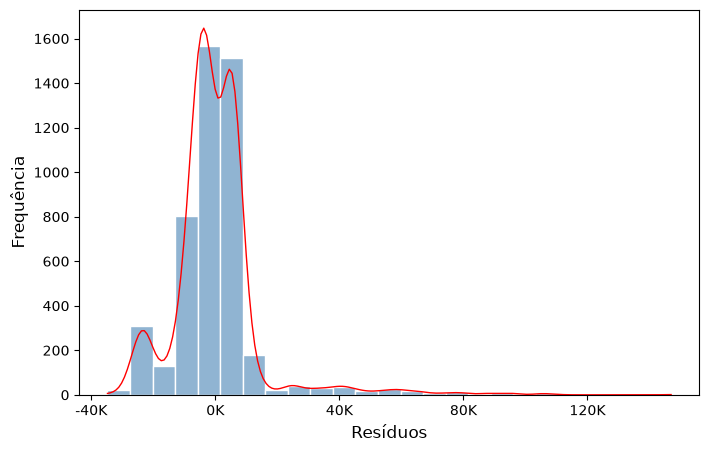

In [ ]:
# Histograma dos resíduos - nao aderentes a normalidade
# Apresenta assimetria forte a direita, com cauda longa à direita (resíduos positivos).
plt.figure(figsize=(8,5))
hist1 = sns.histplot(data=modelo_step_biodiesel.resid, kde=True, bins=25,
                     color = 'steelblue', alpha=0.6, edgecolor='white',
                     line_kws={'linewidth': 1.0})
hist1.get_lines()[0].set_color('red')
plt.xlabel('Resíduos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

hist1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
hist1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig('../outputs/histograma_residuos_step_biodiesel.png', dpi=300, bbox_inches='tight')
plt.show()


#### Modelo 4 (modelo_bc_biodiesel): modelo com transformação de Box-Cox

In [44]:
# Realizando a Transformação Box-Cox para tentar normalizar os resíduos do modelo

# Excluindo observações com quantidade_m3 = 0 (Box-Cox exige valores > 0)
df_mp_dummies_bc = df_mp_dummies[df_mp_dummies['quantidade_m3'] > 0].copy()

# 'yast' traz os valores transformados (Y*), 'lmbda' é o lambda estimado
yast, lmbda = boxcox(df_mp_dummies_bc['quantidade_m3'])

df_mp_dummies_bc['bc_quantidade_m3'] = yast
print(f"Lambda estimado: {lmbda:.4f}")
df_mp_dummies_bc

Lambda estimado: 0.0538


,quantidade_m3,mes,ano,data,tempo,produto_acido_graxo_de_oleo_de_soja,produto_gordura_bovina,produto_gordura_de_frango,produto_gordura_de_porco,produto_oleo_de_algodao_gossypium_hirsut,...,estado_para,estado_parana,estado_piaui,estado_rio_de_janeiro,estado_rio_grande_do_sul,estado_rondonia,estado_santa_catarina,estado_sao_paulo,estado_tocantins,bc_quantidade_m3
0,652,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,7.752813
1,956,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.300739
2,511,8,2023,2023-08-01,80,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,7.409778
3,6595,8,2023,2023-08-01,80,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,11.244582
4,447,8,2023,2023-08-01,80,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,7.223308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4740,14729,1,2017,2017-01-01,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,12.562331
4741,1366,1,2017,2017-01-01,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.821949
4742,325,1,2017,2017-01-01,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.784512
4743,891,1,2017,2017-01-01,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,8.199080


In [45]:
# Reestimando o modelo com a quantidade_m3 transformada por Box-Cox

variaveis_x_step = [re.sub(r"Q\('(.+)'\)", r"\1", nome) 
                     for nome in modelo_step_biodiesel.model.exog_names[1:]]

formula_bc = 'bc_quantidade_m3 ~ ' + ' + '.join(variaveis_x_step)

modelo_bc_biodiesel = sm.OLS.from_formula(formula_bc, df_mp_dummies_bc).fit()
modelo_bc_biodiesel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       bc_quantidade_m3   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     341.2
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:06:40   Log-Likelihood:                -10463.
No. Observations:                4732   AIC:                         2.096e+04
Df Residuals:                    4717   BIC:                         2.105e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
====================================================================================================================
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                            9.5800      0.104     92.233      0.000       9.376       9.784
tempo                                                0.0080      0.001      5.514      0.000       0.005       0.011
produto_acido_graxo_de_oleo_de_soja                 -3.1678      0.204    -15.531      0.000      -3.568      -2.768
produto_gordura_de_frango                           -3.0636      0.133    -23.092      0.000      -3.324      -2.804
produto_gordura_de_porco                            -1.5375      0.129    -11.952      0.000      -1.790      -1.285
produto_oleo_de_algodao_gossypium_hirsut            -1.8086      0.148    -12.242      0.000      -2.098      -1.519
produto_oleo_de_colza_canola_bressica_campestris    -3.5033      0.362     -9.668      0.000      -4.214      -2.793
produto_oleo_de_fritura_usado                       -3.1646      0.114    -27.828      0.000      -3.387      -2.942
produto_oleo_de_milho                               -3.6842      0.191    -19.262      0.000      -4.059      -3.309
produto_oleo_de_soja_glycine_max                     2.6720      0.101     26.359      0.000       2.473       2.871
produto_outros_materiais_graxos                      0.2894      0.110      2.625      0.009       0.073       0.505
regiao_nordeste                                     -0.0591      0.118     -0.502      0.616      -0.290       0.172
regiao_norte                                        -2.7578      0.130    -21.175      0.000      -3.013      -2.502
regiao_sudeste                                      -0.6596      0.088     -7.454      0.000      -0.833      -0.486
regiao_sul                                           0.9676      0.092     10.502      0.000       0.787       1.148
==============================================================================
Omnibus:                      233.033   Durbin-Watson:                   1.858
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              271.824
Skew:                          -0.545   Prob(JB):                     9.42e-60
Kurtosis:                       3.435   Cond. No.                         548.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Modelo 5 (modelo_step_bc_biodiesel): modelo final pós Box-Cox + Stepwise

In [47]:
# Realizando a criacao de novo modelo via Stepwise a partir do modelo Box-Cox

buffer = io.StringIO()
with redirect_stdout(buffer):
    modelo_step_bc_biodiesel = stepwise(modelo_bc_biodiesel, pvalue_limit=0.05)

log_stepwise = buffer.getvalue()

In [49]:
# Verificando quais variáveis foram removidas pelo Stepwise pós Box-Cox

padrao = r"Discarding atribute \"Q\('(.+?)'\)\" with p-value equal to ([\d.eE+-]+)"
removidas = re.findall(padrao, log_stepwise)

df_removidas = pd.DataFrame(removidas, columns=['Variável', 'p-valor'])
df_removidas['p-valor'] = df_removidas['p-valor'].astype(float)
df_removidas = df_removidas.sort_values('p-valor', ascending=False).reset_index(drop=True)
df_removidas

,Variável,p-valor
0,regiao_nordeste,0.615679


In [ ]:
# Modelo final após transformacao de Box-Cox e utilizacao de Stepwise , com todas as variáveis significativas (p-valor < 0.05) e sem multicolinearidade perfeita (VIF = inf).
modelo_step_bc_biodiesel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       bc_quantidade_m3   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.502
Method:                 Least Squares   F-statistic:                     367.5
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:08:17   Log-Likelihood:                -10464.
No. Observations:                4732   AIC:                         2.096e+04
Df Residuals:                    4718   BIC:                         2.105e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
=========================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                 9.5631      0.098     97.320      0.000       9.370       9.756
Q('tempo')                                                0.0080      0.001      5.496      0.000       0.005       0.011
Q('produto_acido_graxo_de_oleo_de_soja')                 -3.1522      0.202    -15.638      0.000      -3.547      -2.757
Q('produto_gordura_de_frango')                           -3.0582      0.132    -23.129      0.000      -3.317      -2.799
Q('produto_gordura_de_porco')                            -1.5317      0.128    -11.957      0.000      -1.783      -1.281
Q('produto_oleo_de_algodao_gossypium_hirsut')            -1.8073      0.148    -12.236      0.000      -2.097      -1.518
Q('produto_oleo_de_colza_canola_bressica_campestris')    -3.5008      0.362     -9.662      0.000      -4.211      -2.790
Q('produto_oleo_de_fritura_usado')                       -3.1623      0.114    -27.832      0.000      -3.385      -2.940
Q('produto_oleo_de_milho')                               -3.6743      0.190    -19.315      0.000      -4.047      -3.301
Q('produto_oleo_de_soja_glycine_max')                     2.6727      0.101     26.372      0.000       2.474       2.871
Q('produto_outros_materiais_graxos')                      0.2908      0.110      2.640      0.008       0.075       0.507
Q('regiao_norte')                                        -2.7396      0.125    -21.903      0.000      -2.985      -2.494
Q('regiao_sudeste')                                      -0.6442      0.083     -7.764      0.000      -0.807      -0.482
Q('regiao_sul')                                           0.9835      0.086     11.373      0.000       0.814       1.153
==============================================================================
Omnibus:                      230.964   Durbin-Watson:                   1.857
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              269.120
Skew:                          -0.542   Prob(JB):                     3.64e-59
Kurtosis:                       3.434   Cond. No.                         547.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [51]:
# Teste de Shapiro-Francia para verificar se os resíduos do modelo com Box-Cox e Stepwise são aderentes à normalidade
# Distribuição dos resíduos do modelo com Box-Cox não é aderente à normalidade, p-valor < 0.05, rejeita-se H0.
teste_sf_bc = shapiro_francia(modelo_step_bc_biodiesel.resid)
teste_sf_bc = teste_sf_bc.items()
method, statistics_W, statistics_z, p = teste_sf_bc
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')

method  :  Shapiro-Francia normality test
statistics W  :  0.9807816865230516
statistics z  :  10.03932408321707
p-value  :  5.118661176798497e-24
Statistics W=0.98078, p-value=0.000000
Rejeita-se H0 - Distribuição não aderente à normalidade


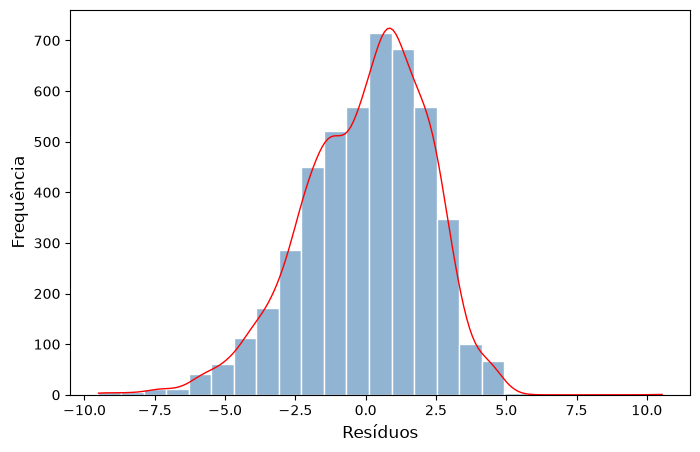

In [ ]:
# Histograma dos resíduos do modelo_step_bc_biodiesel para verificacao visual
# Verificacao visual apresenta melhor adesao a normalidade pelos resíduos, mesmo com Teste de Shapiro-Francia indicando não aderência à normalidade.

plt.figure(figsize=(8,5))
hist2 = sns.histplot(data=modelo_step_bc_biodiesel.resid, kde=True, bins=25,
                     color = 'steelblue', alpha=0.6, edgecolor='white',
                     line_kws={'linewidth': 1.0})
hist2.get_lines()[0].set_color('red')
plt.xlabel('Resíduos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig('../outputs/histograma_residuos_step_bc_biodiesel.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Função para o teste de Breusch-Pagan para a elaboração de diagnóstico de heterocedasticidade

def breusch_pagan_test(modelo):

    df = pd.DataFrame({'yhat':modelo.fittedvalues,
                       'resid':modelo.resid})
   
    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))
   
    modelo_aux = sm.OLS.from_formula('up ~ yhat', df).fit()
   
    anova_table = sm.stats.anova_lm(modelo_aux, typ=2)
   
    anova_table['sum_sq'] = anova_table['sum_sq']/2
    
    chisq = anova_table['sum_sq'].iloc[0]
   
    p_value = stats.chi2.pdf(chisq, 1)*2 # Referencia do Prof. Fávaro
    
    print(f"chisq: {chisq}")
    
    print(f"p-value: {p_value}")
    
    return float(chisq), float(p_value)

In [ ]:
# Teste de Breusch-Pagan no modelo_step_bc_biodiesel

# H0 do teste: ausência de heterocedasticidade.
# H1 do teste: heterocedasticidade, ou seja, correlação entre resíduos e uma ou mais variáveis explicativas, o que indica omissão de variável relevante

teste_bp = breusch_pagan_test(modelo_step_bc_biodiesel)
chisq, p = teste_bp
alpha = 0.05
if p > alpha:
    print('Não se rejeita H0 - Ausência de Heterocedasticidade')
else:
	print('Rejeita-se H0 - Existência de Heterocedasticidade')

chisq: 3.3040688771523583
p-value: 0.08412906743925455
Não se rejeita H0 - Ausência de Heterocedasticidade


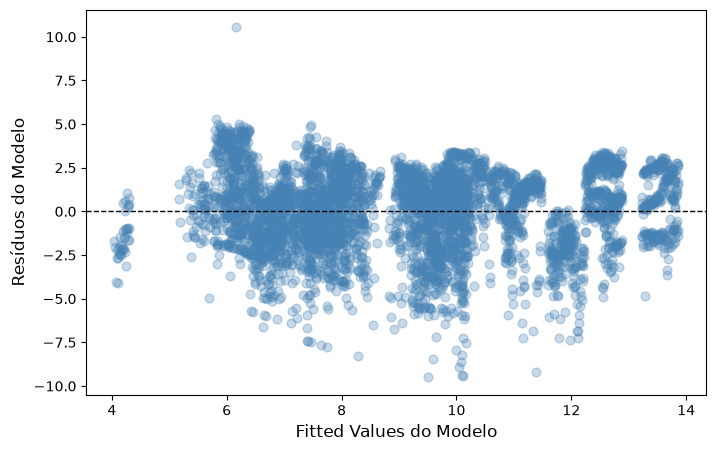

In [56]:
# Gráfico de dispersão dos resíduos do modelo_step_bc_biodiesel em relação aos valores ajustados (fitted values) do modelo para verificação visual de heterocedasticidade
#  Visualmente os resíduos apresentam padrão de dispersão aleatório em torno de zero, sem tendência aparente
 
plt.figure(figsize=(8,5))
sns.regplot(x=modelo_step_bc_biodiesel.fittedvalues, y=modelo_step_bc_biodiesel.resid,
            marker='o', fit_reg=False,
            scatter_kws={"color":'steelblue', 'alpha':0.3, 's':40})
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)  # linha de referência em zero
plt.xlabel('Fitted Values do Modelo', fontsize=12)
plt.ylabel('Resíduos do Modelo', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.savefig('../outputs/residuos_fitted_step_bc_biodiesel.png', dpi=300, bbox_inches='tight')
plt.show()

#### Comparação dos modelos

In [ ]:
# Tabela comparativa consolidada dos modelos ao longo do processo investigativo

modelos = [modelo_biodiesel_1, modelo_biodiesel_2, 
           modelo_step_biodiesel, modelo_step_bc_biodiesel]

comparacao = pd.DataFrame({
    'Modelo': ['modelo_biodiesel_1', 'modelo_biodiesel_2', 
               'modelo_step_biodiesel', 'modelo_step_bc_biodiesel'],
    'Variáveis (k)': [m.df_model for m in modelos],
    'R²': [m.rsquared for m in modelos],
    'R² ajust.': [m.rsquared_adj for m in modelos],
    'Cond. No.': [m.condition_number for m in modelos]
})

skews = []
kurtoses = []
ws = []
ps_shapiro = []

buffer_silencioso = io.StringIO()
with redirect_stdout(buffer_silencioso):
    for m in modelos:
        skews.append(m.resid.skew())
        kurtoses.append(m.resid.kurtosis() + 3) # Kurtosis ABSOLUTA (normal = 3); pandas retorna kurtose em excesso por padrão
        
        teste_sf = shapiro_francia(m.resid).items()
        _, statistics_W, _, p_sf = teste_sf
        ws.append(statistics_W[1])
        ps_shapiro.append(p_sf[1])

comparacao['Skew'] = skews
comparacao['Kurtosis'] = kurtoses 
comparacao['W (Shapiro-Francia)'] = ws
comparacao['p-valor (Shapiro-Francia)'] = ps_shapiro

# Breusch-Pagan (só testado no modelo final) — também com print interno silenciado
with redirect_stdout(buffer_silencioso):
    _, p_bp = breusch_pagan_test(modelo_step_bc_biodiesel)

comparacao['p-valor (Breusch-Pagan)'] = [None, None, None, p_bp]

comparacao

,Modelo,Variáveis (k),R²,R² ajust.,Cond. No.,Skew,Kurtosis,W (Shapiro-Francia),p-valor (Shapiro-Francia),p-valor (Breusch-Pagan)
0,modelo_biodiesel_1,27.0,0.502157,0.499308,1.131581e+16,2.138884,15.128842,0.827671,4.532099e-55,NaN
1,modelo_biodiesel_2,18.0,0.419634,0.417423,3.676343e+03,2.685292,17.671690,0.763099,1.136077e-60,NaN
2,modelo_step_biodiesel,14.0,0.419474,0.417756,5.482146e+02,2.687218,17.676511,0.762949,1.106457e-60,NaN
3,modelo_step_bc_biodiesel,13.0,0.503117,0.501748,5.472425e+02,-0.542542,3.435634,0.980782,5.118661e-24,0.084129


#### Exportação do modelo final

In [63]:
# Criando variáveis auxiliares para salvar o modelo

# Nomes das variáveis explicativas do modelo final, limpando o wrapper Q('...')
variaveis_modelo = [re.sub(r"Q\('(.+)'\)", r"\1", nome) 
                     for nome in modelo_step_bc_biodiesel.model.exog_names[1:]]

# Dummies de produto e região que sobreviveram no modelo final
produtos_no_modelo_final = set(v for v in variaveis_modelo if v.startswith('produto_'))
regioes_no_modelo_final = set(v for v in variaveis_modelo if v.startswith('regiao_'))

In [72]:
# Salvando o modelo final e os artefatos necessários para a previsão
# Salvando o modelo final e os artefatos necessários para a previsão

mapa_tempo_data = {
    row['tempo']: f"{row['mes']:02d}/{row['ano']}" 
    for _, row in df_tempo_referencia.iterrows()
}

artefatos = {
    'modelo': modelo_step_bc_biodiesel,
    'lmbda': lmbda,
    'variaveis_modelo': variaveis_modelo,
    'produtos_disponiveis': sorted(produtos_no_modelo_final),
    'regioes_disponiveis': sorted(regioes_no_modelo_final),
    'todos_produtos': sorted(c.replace('produto_', '') for c in df_mp_dummies.columns if c.startswith('produto_')),
    'todas_regioes': sorted(c.replace('regiao_', '') for c in df_mp_dummies.columns if c.startswith('regiao_')),
    'tempo_min': int(df_mp_dummies_bc['tempo'].min()),
    'tempo_max': int(df_mp_dummies_bc['tempo'].max()),
    'mapa_tempo_data': mapa_tempo_data,
    'produto_referencia': 'ácido graxo de óleo de palma/dendê',
    'regiao_referencia': 'Centro-Oeste',
    
    'aviso_extrapolacao': (
        f"⚠️ Atenção: o valor de tempo informado está fora do intervalo observado "
        f"nos dados de treino ({df_mp_dummies_bc['tempo'].min()}–{df_mp_dummies_bc['tempo'].max()}). "
        f"Esta é uma extrapolação — a confiabilidade da previsão é reduzida, pois o modelo assume que a "
        f"tendência linear observada entre 2017–2023 se mantém."
    ),
    'aviso_limitacao_modelo': (
        "Nota: o modelo explica aproximadamente 50% da variância (R² = 0,503). "
        "Valores muito altos tendem a ser subestimados devido à desconversão "
        "simples do Box-Cox (sem correção de smearing/Duan)."
    )
}

with open('../outputs/modelo_biodiesel_final.pkl', 'wb') as f:
    pickle.dump(artefatos, f)

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
